In [1]:
from PIL import Image

import matplotlib.pyplot as plt
import numpy as np


In [2]:
def texte_vers_binaire(texte):
    """Convertit un string en une chaîne de caractères binaires (8 bits par caractère)."""
    return "".join(format(ord(c), "08b") for c in texte)

def binaire_vers_texte(chaine_binaire):
    """Convertit une chaîne de caractères binaires en string."""
    octets = [chaine_binaire[i:i+8] for i in range(0, len(chaine_binaire), 8)]
    return "".join(chr(int(octet, 2)) for octet in octets if len(octet) == 8)

DELIMITEUR = "#####"


In [3]:
def cacher_message(chemin_image_entree, message_secret, chemin_image_sortie):
    # On ouvre l'image et on s'assure qu'elle est en 8-bits (Niveaux de gris = mode 'L')
    img = Image.open(chemin_image_entree).convert("L")
    pixels = np.array(img)

    # On ajoute le délimiteur à la fin du message et on convertit tout en binaire
    message_complet = message_secret + DELIMITEUR
    message_binaire = texte_vers_binaire(message_complet)

    # On aplatit le tableau de pixels en 1D pour faciliter le parcours
    pixels_plats = pixels.flatten()

    # Vérification de la capacité de l'image
    if len(message_binaire) > len(pixels_plats):
        raise ValueError("Message is too long for the image.")

    # Remplacement du bit de poids faible (LSB)
    for i in range(len(message_binaire)):
        bit_a_cacher = int(message_binaire[i])
        # L'opération bit à bit '& 254' force le dernier bit à 0, puis on fait un 'OU' avec notre bit
        pixels_plats[i] = (pixels_plats[i] & 254) | bit_a_cacher

    # On redonne à l'image sa forme originale et on sauvegarde
    pixels_modifies = pixels_plats.reshape(pixels.shape)
    img_modifiee = Image.fromarray(pixels_modifies, mode="L")
    img_modifiee.save(chemin_image_sortie, format="BMP")
    print(f"Message succesfully hidden in : {chemin_image_sortie}")

# --- 3. FONCTION POUR EXTRAIRE LE MESSAGE (DÉCODAGE LSB) ---

def extraire_message(chemin_image):
    # On ouvre l'image modifiée
    img = Image.open(chemin_image).convert("L")
    pixels_plats = np.array(img).flatten()

    bits_extraits = []

    # On récupère le dernier bit de chaque pixel
    for pixel in pixels_plats:
        bits_extraits.append(str(pixel & 1))

    chaine_binaire_complete = "".join(bits_extraits)

    # On lit le binaire par paquets de 8 bits (1 octet = 1 caractère)
    message_decode = ""
    for i in range(0, len(chaine_binaire_complete), 8):
        octet = chaine_binaire_complete[i:i+8]
        if len(octet) < 8:
            break
        caractere = chr(int(octet, 2))
        message_decode += caractere

        # On s'arrête si on détecte le délimiteur
        if message_decode.endswith(DELIMITEUR):
            # On retourne le message sans le délimiteur
            return message_decode[:-len(DELIMITEUR)]

    return "No hidden message found (or delimiter not found)."


In [4]:
nom_fichier_sortie = "image_secrete.bmp"
mon_message = "Decode this!"


In [5]:
# 1. On définit la taille de l'image (par exemple 256 pixels par 256 pixels)
largeur, hauteur = 256, 256

# 2. On crée un tableau rempli de zéros (qui correspondra à du noir)
pixels = np.zeros((hauteur, largeur), dtype=np.uint8)

# 3. On crée un dégradé horizontal
# Chaque colonne prend la valeur de son index (de 0 à 255)
for x in range(largeur):
    pixels[:, x] = x

# 4. On convertit le tableau NumPy en image PIL (mode 'L' = 8 bits niveaux de gris)
image_test = Image.fromarray(pixels, mode="L")

# 5. On sauvegarde le fichier au format BMP
nom_fichier = "image_test_8bits.bmp"
image_test.save(nom_fichier, format="BMP")

print(f"Image '{nom_fichier}' created successfully!")


Image 'image_test_8bits.bmp' created successfully!


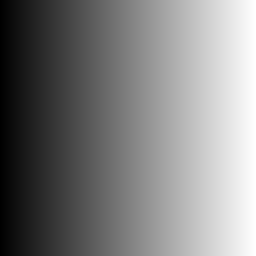

Message succesfully hidden in : image_secrete.bmp


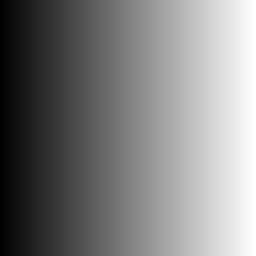

Message : Decode this!


In [6]:
display(Image.open(nom_fichier))
# 2. Cacher le message
cacher_message(nom_fichier, mon_message, nom_fichier_sortie)

#display the image
display(Image.open(nom_fichier_sortie))

# 3. Extraire le message
message_trouve = extraire_message(nom_fichier_sortie)
print(f"Message : {message_trouve}")


In [7]:
image_sortie = Image.open(nom_fichier_sortie)


In [8]:
# 1. Préparation d'un LONG message pour que l'effet stégo soit visible
# On crée un faux message assez long pour remplir une bonne partie de l'image (256x256 = 65536 pixels)
long_message = "Check if we can decode everything, like long messages" * 200
image_originale = "image_test_8bits.bmp"
image_stego = "image_secrete.bmp"

# On cache ce long message dans notre image de test
cacher_message(image_originale, long_message, image_stego)

# 2. Fonction pour extraire tous les LSB d'une image
def extraire_tous_les_lsb(chemin_image):
    img = Image.open(chemin_image).convert("L")
    pixels = np.array(img).flatten()
    # On récupère uniquement le dernier bit avec l'opérateur '& 1'
    return pixels & 1

# On extrait les LSB des deux images
lsb_orig = extraire_tous_les_lsb(image_originale)
lsb_stego = extraire_tous_les_lsb(image_stego)

# 3. Création des graphiques avec Matplotlib
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5)) # 1 ligne, 2 colonnes

# --- Graphique de gauche : Image Stego ---
ax1.hist(lsb_stego, bins=[-0.5, 0.5, 1.5], edgecolor="black", alpha=0.7)
ax1.set_title("Histogramme des LSB - Image Stego")
ax1.set_xticks([0, 1])
ax1.set_xticklabels(["LSB=0", "LSB=1"])
ax1.set_ylabel("Nombre d'occurrences")

# --- Graphique de droite : Image Originale ---
ax2.hist(lsb_orig, bins=[-0.5, 0.5, 1.5], edgecolor="black", alpha=0.7)
ax2.set_title("Histogramme des LSB - Image Originale")
ax2.set_xticks([0, 1])
ax2.set_xticklabels(["LSB=0", "LSB=1"])
ax2.set_ylabel("Nombre d'occurrences")

# Affichage du résultat
plt.tight_layout()
plt.show()


ValueError: Message is too long for the image.

GSB

In [ ]:
def cacher_messageGSB(chemin_image_entree, message_secret, chemin_image_sortie):
    # On ouvre l'image et on s'assure qu'elle est en 8-bits (Niveaux de gris = mode 'L')
    img = Image.open(chemin_image_entree).convert("L")
    pixels = np.array(img)

    # On ajoute le délimiteur à la fin du message et on convertit tout en binaire
    message_complet = message_secret + DELIMITEUR
    message_binaire = texte_vers_binaire(message_complet)

    # On aplatit le tableau de pixels en 1D pour faciliter le parcours
    pixels_plats = pixels.flatten()

    # Vérification de la capacité de l'image
    if len(message_binaire) > len(pixels_plats):
        raise ValueError("The image is too small.")

    # Remplacement du bit de poids faible (LSB)
    for i in range(len(message_binaire)):
        bit_a_cacher = int(message_binaire[i])
        # bit_a_cacher << 7 décale le bit de 7 crans vers la gauche
        pixels_plats[i] = (pixels_plats[i] & 127) | (bit_a_cacher << 7)

    # On redonne à l'image sa forme originale et on sauvegarde
    pixels_modifies = pixels_plats.reshape(pixels.shape)
    img_modifiee = Image.fromarray(pixels_modifies, mode="L")
    img_modifiee.save(chemin_image_sortie, format="BMP")
    print(f"Message well hidden within : {chemin_image_sortie}")

# --- 3. FONCTION POUR EXTRAIRE LE MESSAGE (DÉCODAGE LSB) ---

def extraire_messageGSB(chemin_image):
    # On ouvre l'image modifiée
    img = Image.open(chemin_image).convert("L")
    pixels_plats = np.array(img).flatten()

    bits_extraits = []

    # On récupère le dernier bit de chaque pixel
    for pixel in pixels_plats:
        # On isole le bit de poids fort, puis on le ramène tout à droite
        bits_extraits.append(str((pixel & 128) >> 7))

    chaine_binaire_complete = "".join(bits_extraits)

    # On lit le binaire par paquets de 8 bits (1 octet = 1 caractère)
    message_decode = ""
    for i in range(0, len(chaine_binaire_complete), 8):
        octet = chaine_binaire_complete[i:i+8]
        if len(octet) < 8:
            break
        caractere = chr(int(octet, 2))
        message_decode += caractere

        # On s'arrête si on détecte le délimiteur
        if message_decode.endswith(DELIMITEUR):
            # On retourne le message sans le délimiteur
            return message_decode[:-len(DELIMITEUR)]

    return "No hidden message found (or delimiter not found)."


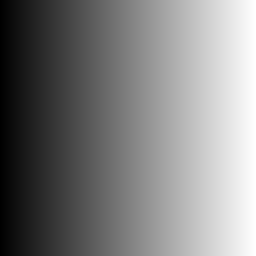

Message well hidden within : image_secrete.bmp


/var/folders/qx/qc20ksl50kb3r1gbtqwgqm2h0000gn/T/ipykernel_3336/3844268843.py:25: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_modifiee = Image.fromarray(pixels_modifies, mode='L')


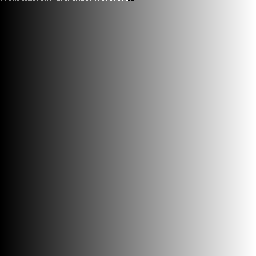

Message : Decode this!


In [ ]:
display(Image.open(nom_fichier))
# 2. Cacher le message
cacher_messageGSB(nom_fichier, mon_message, nom_fichier_sortie)

#display the image
display(Image.open(nom_fichier_sortie))

# 3. Extraire le message
message_trouve = extraire_messageGSB(nom_fichier_sortie)
print(f"Message : {message_trouve}")


Avec une clé

In [ ]:
def generer_positions(cle, nb_bits_necessaires, max_pixels):
    # On transforme la clé (ex: 1369) en une liste d'entiers [1, 3, 6, 9]
    sauts = [int(chiffre) for chiffre in str(cle)]

    positions = []
    pos_actuelle = 0

    for i in range(nb_bits_necessaires):
        saut = sauts[i % len(sauts)]
        # Sécurité : si un chiffre de la clé est 0, on avance d'au moins 1
        # pour ne pas écraser le même pixel
        if saut == 0:
            saut = 1

        pos_actuelle += saut

        # On vérifie qu'on ne dépasse pas la fin de l'image
        if pos_actuelle >= max_pixels:
            raise ValueError(f"The image is too small. It can only hold {i} bits with this key.")

        positions.append(pos_actuelle)

    return positions

# --- 2. ENCODAGE AVEC CLÉ ---

def cacher_message_cle(chemin_image_entree, message_secret, cle, chemin_image_sortie):
    img = Image.open(chemin_image_entree).convert("L")
    pixels_plats = np.array(img).flatten()

    message_binaire = texte_vers_binaire(message_secret + DELIMITEUR)

    # On génère exactement les positions dont on a besoin
    positions = generer_positions(cle, len(message_binaire), len(pixels_plats))

    # On remplace les LSB uniquement sur ces positions précises
    for i in range(len(message_binaire)):
        pos = positions[i]
        bit_a_cacher = int(message_binaire[i])
        pixels_plats[pos] = (pixels_plats[pos] & 254) | bit_a_cacher

    img_modifiee = Image.fromarray(pixels_plats.reshape(np.array(img).shape), mode="L")
    img_modifiee.save(chemin_image_sortie, format="BMP")
    print(f"Hidden message found with key '{cle}' !")

# --- 3. DÉCODAGE AVEC CLÉ ---

def extraire_message_cle(chemin_image, cle):
    img = Image.open(chemin_image).convert("L")
    pixels_plats = np.array(img).flatten()

    sauts = [int(chiffre) for chiffre in str(cle)]
    pos_actuelle = 0
    index_saut = 0

    bits_extraits = ""
    message_decode = ""

    # On parcourt l'image en sautant de pixel en pixel selon la clé
    while pos_actuelle < len(pixels_plats):
        saut = sauts[index_saut % len(sauts)]
        if saut == 0: saut = 1
        pos_actuelle += saut

        if pos_actuelle >= len(pixels_plats):
            break

        # On extrait le bit
        bits_extraits += str(pixels_plats[pos_actuelle] & 1)
        index_saut += 1

        # Tous les 8 bits, on convertit en texte
        if len(bits_extraits) == 8:
            message_decode += chr(int(bits_extraits, 2))
            bits_extraits = ""

            # On s'arrête si on trouve le délimiteur
            if message_decode.endswith(DELIMITEUR):
                return message_decode[:-len(DELIMITEUR)]

    return "No hidden message found."


In [ ]:
image_originale = "image_test_8bits.bmp"
image_stego_cle = "image_test_stego_cle.bmp"
mon_message = "Try out keys!"
ma_cle = 1369

# 1. On cache
cacher_message_cle(image_originale, mon_message, ma_cle, image_stego_cle)

# 2. On extrait avec la BONNE clé
print("Test right key :", extraire_message_cle(image_stego_cle, 1369))

# 3. On extrait avec une MAUVAISE clé (ça devrait sortir n'importe quoi ou échouer)
print("Test wrong key :", extraire_message_cle(image_stego_cle, 4444))


Hidden message found with key '1369' !
Test right key : Try out keys!
Test wrong key : No hidden message found.


/var/folders/qx/qc20ksl50kb3r1gbtqwgqm2h0000gn/T/ipykernel_3336/840764186.py:42: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img_modifiee = Image.fromarray(pixels_plats.reshape(np.array(img).shape), mode='L')
